# EPC Analysis: Camden, London

The first notebook profiled the raw data and found where it is wrong. The second cleaned it, adding flags rather than deleting records. This notebook uses the result.

Planned questions:
1. What condition is Camden's housing stock in, and how much of it falls below band C?
2. How much CO2 could be saved if the recommended improvements were carried out?
3. How is that saving split between homes needing insulation and homes needing a new heating system? The two require different money and different policy.
4. How different is the answer if certificates are counted instead of homes? This tests whether the cleaning work changes conclusions or only tidies them.

Two sections were added along the way that were not planned: what the recommended work does to a household's bill, and how old the evidence behind the enforcement cases actually is. One planned question was dropped, whether the age or type of a home predicts its rating. The cleaned file carries construction_year_est and property_type so it can be asked, but the sections that opened up all fed the same argument about enforcement, and age would have sat apart from it.

The data quality report cites this notebook for two findings: the tenure gap behind finding 3, in Section 4, and the staleness of certificates behind finding 1, in Section 8.


## 1. Load the cleaned data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

work = pd.read_csv("../data/processed/camden_certificates_cleaned.csv", low_memory=False)

print("Rows:", len(work))
print("Columns:", work.shape[1])

Rows: 102185
Columns: 116


## 2. Reduce to one record per home

The file holds every certificate ever lodged, and homes are recertificated on sale or re-let,
so a home can appear many times. The cleaning notebook marked the most recent certificate for
each home with is_latest, so filtering on it gives one current record per home.

In [2]:
homes = work[work['is_latest']].copy()

print("Certificates in the file:", len(work))
print("Homes after keeping the latest each:", len(homes))
print("Certificates removed as older records:", len(work) - len(homes))

Certificates in the file: 102185
Homes after keeping the latest each: 83675
Certificates removed as older records: 18510


18,510 certificates, roughly one in five, are superseded records for homes that were
certificated again later. Counting ratings straight off the full file would count those
homes more than once, over-weighting properties that change hands often.

One caveat on the 83,675. A home is identified by its UPRN plus its address, but 7,930
of these homes have no UPRN, so they are identified by address alone. If a home was
certificated once without a UPRN and again with one, it gets two different identifiers
and is counted twice.

The check below measures how often that can happen: it counts homes in the no-UPRN group
whose address also appears in the group that does have UPRNs. Those are the only ones at
risk of being counted twice.

In [3]:
noup = work.loc[~work['uprn_present'] & work['is_latest'], 'address_clean']
hasup = set(work.loc[work['uprn_present'], 'address_clean'])

print("Homes identified by address alone:", len(noup))
print("Of those, address also appears in the UPRN group:", noup.isin(hasup).sum())

Homes identified by address alone: 7930
Of those, address also appears in the UPRN group: 175


175 out of 7,930. The other 7,755 sit at addresses that appear nowhere else, so they are
counted once and correctly.

175 is a ceiling, not a count. A shared address does not prove the same dwelling, since two
flats in one building can share the same address text when the flat number is not recorded.
So the real double count is somewhere between 0 and 175, which is at most 0.2% of the total.
Immaterial for percentages, but worth stating if the figure is quoted on its own.

The cleaning notebook also flagged records with values that cannot be true, or that were lodged in a way that suggests a problem. Those flags are not applied here as a block. Which ones matter depends on the question: a wrong lodgement date does not invalidate a rating, and same-day duplicates have already been resolved by keeping the latest record. Each section below states which flags it applies and why. This shows how many homes each affects before any are used.

In [4]:
flags = ['floor_area_implausible', 'floor_area_very_large',
         'negative_emissions', 'negative_energy',
         'lodged_before_inspection', 'same_day_duplicate']

print("Homes carrying each quality flag:")
for c in flags:
    print(f"  {c:26} {homes[c].sum():>5}")

Homes carrying each quality flag:
  floor_area_implausible        76
  floor_area_very_large        261
  negative_emissions            24
  negative_energy               34
  lodged_before_inspection     484
  same_day_duplicate           310


## 3. What condition is Camden's housing in?

The rating runs from A, best, to G, worst. Band C is the level privately rented homes must reach by 2030, so the share below C is the size of the problem.

No quality flags are applied here, and that is a judgement about scale rather than relevance. Floor area does feed the rating, since the rating measures energy use per square metre, so a home recorded at 3 m2 carries a distorted rating as well as a distorted area. But the two floor area flags cover 76 and 261 homes out of 83,675, too few to move a percentage at this level. The emissions and date flags do not enter the rating calculation at all.

In [5]:
rating_counts = homes['current_energy_rating'].value_counts().sort_index()
rating_pct = (rating_counts / len(homes) * 100).round(1)

print(pd.DataFrame({'homes': rating_counts, 'percent': rating_pct}))
print()
print("Total:", rating_counts.sum())

                       homes  percent
current_energy_rating                
A                         80      0.1
B                      10374     12.4
C                      37616     45.0
D                      28131     33.6
E                       6569      7.9
F                        694      0.8
G                        211      0.3

Total: 83675


In [6]:
below_c = homes['current_energy_rating'].isin(['D', 'E', 'F', 'G'])
f_or_g = homes['current_energy_rating'].isin(['F', 'G'])

print(f"Below band C: {below_c.sum()} ({below_c.mean()*100:.1f}%)")
print(f"At F or G:    {f_or_g.sum()} ({f_or_g.mean()*100:.1f}%)")

Below band C: 35605 (42.6%)
At F or G:    905 (1.1%)


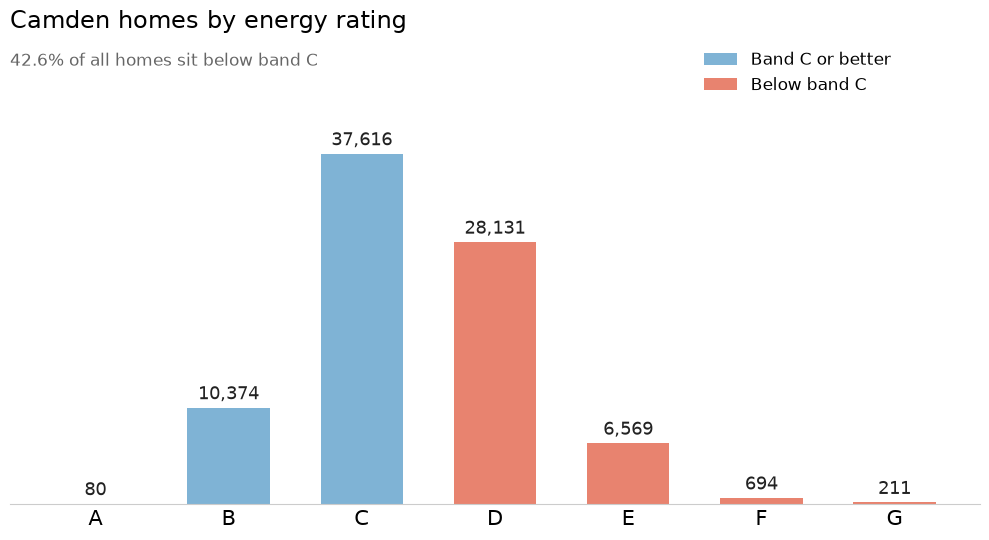

In [7]:
from matplotlib.patches import Patch

good, bad = '#7fb3d5', '#e8836f'

fig, ax = plt.subplots(figsize=(10, 5.5))

colours = [good if r in ('A', 'B', 'C') else bad for r in rating_counts.index]
ax.bar(rating_counts.index, rating_counts.values, color=colours, width=0.62)

for i, v in enumerate(rating_counts.values):
    ax.text(i, v + 900, f"{v:,}", ha='center', fontsize=13, color='#222222')

ax.set_title("Camden homes by energy rating", fontsize=17, loc='left', pad=45)
ax.text(0, 1.06, f"{below_c.mean()*100:.1f}% of all homes sit below band C",
        transform=ax.transAxes, fontsize=12.5, color='#666666')

ax.legend(handles=[Patch(facecolor=good), Patch(facecolor=bad)],
          labels=['Band C or better', 'Below band C'],
          frameon=False, fontsize=12, loc='upper left', bbox_to_anchor=(0.70, 1.13))

ax.set_ylim(0, rating_counts.max() * 1.18)
ax.get_yaxis().set_visible(False)
for side in ['top', 'right', 'left']:
    ax.spines[side].set_visible(False)
ax.spines['bottom'].set_color('#cccccc')
ax.tick_params(axis='x', length=0, labelsize=15)

plt.tight_layout()
plt.savefig("../outputs/rating_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

Band A is 80 homes, too few to register at this scale.

Every home has a rating, with no missing values, which is another case of the register enforcing a rule where it has one.

Most of Camden sits in the middle: C and D together hold 78.6% of homes. Only 80 homes reach band A.

The figure that matters is not in the table. 35,605 homes, 42.6%, fall below band C, which is the standard privately rented homes must reach by 2030. 905 homes are at F or G, which is already unlawful to let privately without a registered exemption.

The band C and F or G thresholds come from the Minimum Energy Efficiency Standards, not from this data. See the note at the end of outputs/data_quality_report.md for the regulations.

## 4. Who occupies the homes that fall short?

42.6% below band C is only meaningful once you know who lives in those homes. The 2030
standard applies to privately rented homes, not to owner-occupiers, so the headline figure
mixes homes the law will reach with homes it will not.

This uses tenure_clean, the standardised version from the cleaning notebook, since the raw
tenure column records the same category more than one way.

In [8]:
below = homes[homes['current_energy_rating'].isin(['D', 'E', 'F', 'G'])]

tenure_counts = below['tenure_clean'].value_counts(dropna=False)
tenure_pct = (tenure_counts / len(below) * 100).round(1)

print("Tenure of the 35,605 homes below band C:")
print(pd.DataFrame({'homes': tenure_counts, 'percent': tenure_pct}))

Tenure of the 35,605 homes below band C:
                  homes  percent
tenure_clean                    
rented (private)  14090     39.6
owner-occupied    12220     34.3
rented (social)    7485     21.0
NaN                 934      2.6
unknown             876      2.5


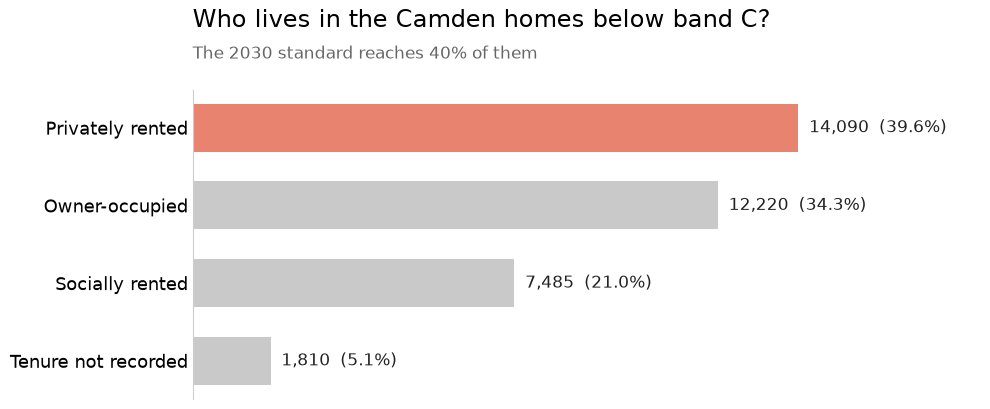

In [9]:
order = ['rented (private)', 'owner-occupied', 'rented (social)']
labels = ['Privately rented', 'Owner-occupied', 'Socially rented', 'Tenure not recorded']

vals = [tenure_counts.get(k, 0) for k in order]
vals.append(len(below) - sum(vals))

reach, no_reach = '#e8836f', '#c9c9c9'
colours = [reach, no_reach, no_reach, no_reach]

fig, ax = plt.subplots(figsize=(10, 4.2))

bars = ax.barh(labels[::-1], vals[::-1], color=colours[::-1], height=0.62)

for y, v in enumerate(vals[::-1]):
    ax.text(v + 250, y, f"{v:,}  ({v / len(below) * 100:.1f}%)",
            va='center', fontsize=12.5, color='#222222')

ax.set_title("Who lives in the Camden homes below band C?",
             fontsize=17, loc='left', pad=45)
ax.text(0, 1.10,
        f"The 2030 standard reaches {vals[0] / len(below) * 100:.0f}% of them",
        transform=ax.transAxes, fontsize=12.5, color='#666666')

ax.set_xlim(0, max(vals) * 1.30)
ax.get_xaxis().set_visible(False)
for side in ['top', 'right', 'bottom']:
    ax.spines[side].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.tick_params(axis='y', length=0, labelsize=13)

plt.tight_layout()
plt.savefig("../outputs/tenure_below_c.png", dpi=150, bbox_inches='tight')
plt.show()

The 35,605 splits into three different problems.

14,090 are privately rented, 39.6% of the shortfall. This is the group the 2030 standard
reaches, so the enforceable problem is roughly 14,000 homes rather than 35,605.

12,220 are owner-occupied, 34.3%. No law requires these to improve, so they need grants or
incentives rather than enforcement.

7,485 are socially rented, 21.0%. These sit outside MEES but are being brought under a
separate standard from 2026.

1,810, 5.1%, cannot be assigned to any of the three, because tenure is unknown or blank. For
those homes it is not possible to say which policy applies.

In [10]:
usable = work[work['tenure_clean'].isin(['owner-occupied', 'rented (private)', 'rented (social)'])]
per_home = usable.groupby('property_key')['tenure_clean'].agg(['size', 'nunique'])
multi = per_home[per_home['size'] > 1]

print("Homes with a usable tenure on more than one certificate:", len(multi))
print("Of those, tenure differs between records:", (multi['nunique'] > 1).sum())
print(f"Share: {(multi['nunique'] > 1).mean() * 100:.1f}%")

Homes with a usable tenure on more than one certificate: 12620
Of those, tenure differs between records: 4605
Share: 36.5%


Tenure is recorded at inspection, not maintained. Looking across every certificate a home has
ever had, not just the latest, 36.5% of homes with more than one usable tenure record show a
different tenure between them, so a home recorded as
privately rented in 2016 may be owner-occupied now. These figures describe what was recorded
at the last inspection, not necessarily what is true today.

## 5. How much CO2 could be saved?

Each certificate records current emissions and potential emissions, the latter being what the home would emit if the recommended improvements were carried out. The difference between the two totals is the saving available with known measures.

This is the first question where quality flags matter. 24 homes record negative current emissions, which is impossible and would subtract from the total, so they are excluded and the number excluded is reported rather than quietly dropped.

The floor area flags matter here too, in a way they did not for the rating, because emissions are a total rather than a rate. A percentage is barely moved by 337 homes, but a sum is, since a home recorded at 3,337 m2 contributes in proportion to its size. The two floor area flags are tested separately rather than pooled, because they are not the same kind of problem: under 10 m2 is impossible, while over 500 m2 is unusual but often genuine in Camden.

In [11]:
co2 = homes[~homes['negative_emissions']].copy()

current = co2['co2_emissions_current'].sum()
potential = co2['co2_emissions_potential'].sum()

def totals(df, label):
    cur = df['co2_emissions_current'].sum()
    pot = df['co2_emissions_potential'].sum()
    print(f"{label:34} {len(df):>6,}  {cur:>9,.0f}  {pot:>9,.0f}  {cur-pot:>8,.0f}  {(cur-pot)/cur*100:5.1f}%")

print("Homes in this calculation:", len(co2))
print("Excluded for negative emissions:", homes['negative_emissions'].sum())
print()
print(f"{'':34} {'homes':>6}  {'current':>9}  {'potential':>9}  {'saving':>8}  reduction")
totals(co2, "As reported")
totals(co2[~co2['floor_area_implausible']], "Excluding under 10 m2")
totals(co2[~co2['floor_area_very_large']], "Excluding over 500 m2")
totals(co2[~co2['floor_area_implausible'] & ~co2['floor_area_very_large']], "Excluding both")
print()

flagged = co2[co2['floor_area_implausible'] | co2['floor_area_very_large']]
print("Homes carrying either floor area flag:", len(flagged))
print(f"Their share of all homes:             {len(flagged) / len(co2) * 100:.1f}%")
print(f"Their share of current emissions:     {flagged['co2_emissions_current'].sum() / current * 100:.1f}%")

Homes in this calculation: 83651
Excluded for negative emissions: 24

                                    homes    current  potential    saving  reduction
As reported                        83,651    231,068    148,121    82,947   35.9%
Excluding under 10 m2              83,575    230,983    148,048    82,935   35.9%
Excluding over 500 m2              83,390    225,540    144,311    81,229   36.0%
Excluding both                     83,314    225,455    144,238    81,217   36.0%

Homes carrying either floor area flag: 337
Their share of all homes:             0.4%
Their share of current emissions:     2.4%


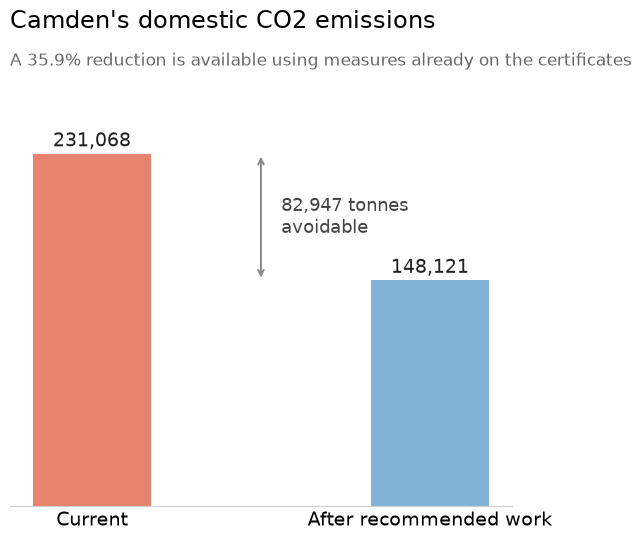

In [12]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))

ax.bar(['Current', 'After recommended work'], [current, potential],
       color=['#e8836f', '#7fb3d5'], width=0.35)

ax.text(0, current + 5000, f"{current:,.0f}", ha='center', fontsize=14, color='#222222')
ax.text(1, potential + 5000, f"{potential:,.0f}", ha='center', fontsize=14, color='#222222')

ax.annotate('', xy=(0.5, potential), xytext=(0.5, current),
            arrowprops=dict(arrowstyle='<->', color='#888888', lw=1.4))
ax.text(0.56, (current + potential) / 2,
        f"{current - potential:,.0f} tonnes\navoidable",
        fontsize=13, color='#444444', va='center')

ax.set_title("Camden's domestic CO2 emissions", fontsize=17, loc='left', pad=45)
ax.text(0, 1.06,
        f"A {(current - potential) / current * 100:.1f}% reduction is available using measures already on the certificates",
        transform=ax.transAxes, fontsize=12.5, color='#666666')

ax.set_ylim(0, current * 1.18)
ax.get_yaxis().set_visible(False)
for side in ['top', 'right', 'left']:
    ax.spines[side].set_visible(False)
ax.spines['bottom'].set_color('#cccccc')
ax.tick_params(axis='x', length=0, labelsize=13.5)

plt.tight_layout()
plt.savefig("../outputs/co2_gap.png", dpi=150, bbox_inches='tight')
plt.show()

Camden's homes emit 231,068 tonnes of CO2 a year on their current records. If every improvement recommended on those certificates were carried out, that would fall to 148,121 tonnes, a saving of 82,947 tonnes a year, or 35.9%.

The 337 homes with a flagged floor area are 0.4% of the stock but 2.4% of these emissions, roughly six times their weight, which is what a size-based flag should do. Removing both flags takes the saving to 81,217 tonnes and the reduction to 36.0%, and almost all of that movement comes from the over 500 m2 group rather than the impossible one. The figure is reported with those homes included, since a house over 500 m2 in Camden is usually real and excluding it would understate the total. The check matters less for the answer than for what it rules out: the headline does not depend on the records the audit found fault with.

The measures are already specified on the certificates, so this is not a projection about future technology. It is the gap between what these homes do and what they could do with work an assessor has already identified.

Two limits on the figure. It assumes every recommendation is carried out on every home, which no programme achieves. And the potential rating is the assessor's estimate rather than a measured result.

## 6. What kind of work does that saving need?

82,947 tonnes is a single number covering two different problems. A gas-heated home needs its
heating system replaced to decarbonise, which is expensive and disruptive. An electrically
heated home mostly needs insulation. The two need different money and different trades, so the
saving is more useful once it is split.

The main_fuel column records how each home is heated. Look at what it contains before using it.

In [13]:
print("Distinct values:", homes['main_fuel'].nunique(dropna=False))
print()
print(homes['main_fuel'].value_counts(dropna=False))

Distinct values: 26

main_fuel
mains gas (not community)                                                                        49625
mains gas (community)                                                                            16000
electricity (not community)                                                                       7409
NaN                                                                                               6850
Gas: mains gas                                                                                    1685
Electricity: electricity, unspecified tariff                                                      1304
electricity (community)                                                                            371
To be used only when there is no heating/hot-water system or data is from a community network      213
oil (community)                                                                                     55
LPG (not community)                       

26 values, with the same drift seen elsewhere: "mains gas (not community)" and "Gas: mains gas" are the same fuel recorded by different software generations, as are the two forms of electricity. Two values are not fuels at all but instructions to the assessor stored in the data field. 6,850 homes have no fuel value at all, and 7,125 have nothing usable once the instruction strings are counted with them.

Grouping used here: gas covers mains gas and biogas, community or not. Electricity covers both recorded forms. Other fuel covers oil, LPG, coal, biomass, wood and waste combustion. Not recorded covers blanks and the instruction strings.

Community heating is grouped with its underlying fuel, since a community gas system still burns gas. The community share is reported separately below, because those homes cannot change their heating individually even though the fuel is the same. One instruction string reads "no heating/hot-water system or data is from a community network", which describes two different situations in one value, so those rows cannot be assigned either way. They are counted as not recorded for fuel, and the community total is reported with and without them.

In [14]:
fuel = homes['main_fuel'].astype('string').str.lower()

def group_fuel(v):
    if pd.isna(v):
        return 'not recorded'
    if 'to be used only' in v or 'heat network data' in v:
        return 'not recorded'
    if 'gas' in v and 'lpg' not in v:
        return 'gas'
    if 'electricity' in v:
        return 'electricity'
    return 'other fuel'

homes['fuel_group'] = fuel.apply(group_fuel)

fuel_counts = homes['fuel_group'].value_counts()
known = homes[homes['fuel_group'] != 'not recorded']

summary = pd.DataFrame({
    'homes': fuel_counts,
    'percent of all homes': (fuel_counts / len(homes) * 100).round(1),
    'percent where fuel is known': (fuel_counts / len(known) * 100).round(1)
})
summary.loc['not recorded', 'percent where fuel is known'] = float('nan')

print(summary)
print()
print("Homes with no fuel value at all:", homes['main_fuel'].isna().sum())
print("Homes counted as not recorded, including instruction strings:", len(homes) - len(known))
print("Homes with a usable fuel:", len(known))
print()

community = fuel.str.contains('community', na=False) & ~fuel.str.contains('not community', na=False)
ambiguous = fuel.str.contains('to be used only', na=False) & community

print("On a community heating network, ambiguous rows included:", community.sum())
print("Rows using the ambiguous instruction string:            ", ambiguous.sum())
print("On a community heating network, ambiguous rows excluded:", (community & ~ambiguous).sum())

              homes  percent of all homes  percent where fuel is known
fuel_group                                                            
gas           67311                  80.4                         87.9
electricity    9084                  10.9                         11.9
not recorded   7125                   8.5                          NaN
other fuel      155                   0.2                          0.2

Homes with no fuel value at all: 6850
Homes counted as not recorded, including instruction strings: 7125
Homes with a usable fuel: 76550

On a community heating network, ambiguous rows included: 16684
Rows using the ambiguous instruction string:             213
On a community heating network, ambiguous rows excluded: 16471


80.4% of Camden's homes are heated by gas, or 87.9% of the homes where a fuel is recorded. Only 10.9% run on electricity, 11.9% where fuel is known, and there the route to lower emissions is mostly insulation rather than plant replacement.

That reframes the 82,947 tonnes. It is not mainly an insulation problem, it is a heating problem, and replacing a gas boiler with a heat pump costs and disrupts far more than insulating a loft.

Between 16,471 and 16,684 homes, close to 20% of the total, are on a community heating network. The range is the 213 rows carrying the ambiguous instruction string. Those homes cannot change their heating individually. The decision sits with whoever operates the network, so a policy aimed at individual households does not reach them.

## 7. Does the recommended work reduce bills?

The saving in Section 5 is measured in emissions, which is not what a household decides on.
People decide on cost. Each certificate records the current heating cost and the cost after
the recommended improvements, so the same question can be asked in pounds.

Two limits. The potential cost assumes the assessor's recommended package, which is usually
insulation and controls rather than a change of heating system. And each certificate uses the
energy prices of the year it was lodged, so these figures show the direction of the effect
rather than a current bill.

In [15]:
check = homes.copy()
check['saving'] = check['heating_cost_current'] - check['heating_cost_potential']

print("Share with no change, by fuel group:")
print(check.groupby('fuel_group')['saving'].apply(lambda s: (s == 0).mean() * 100).round(1))
print()
print("Homes with a heating cost of zero:", (check['heating_cost_current'] == 0).sum())

Share with no change, by fuel group:
fuel_group
electricity     25.8
gas             13.0
not recorded    92.2
other fuel      15.5
Name: saving, dtype: float64

Homes with a heating cost of zero: 2


92.2% of the homes with no recorded fuel show no change at all between current and potential
cost, against 13% for gas and 25.8% for electricity. Those certificates appear to carry no
recommendations, so they say nothing about whether retrofit saves money. They are excluded
from the comparison below.

Only 2 homes record a heating cost of zero, so that is not a problem.

In [16]:
cost = homes[homes['fuel_group'] != 'not recorded'].copy()
cost['saving'] = cost['heating_cost_current'] - cost['heating_cost_potential']

print("Homes with a recorded fuel:", len(cost))
print()
print(cost.groupby('fuel_group')['saving'].agg(['count', 'median', 'mean']).round(0))
print()
print("No change to the bill:", (cost['saving'] == 0).sum())
print("Bill increases:       ", (cost['saving'] < 0).sum())
print("Bill decreases:       ", (cost['saving'] > 0).sum())
print()

no_gain = (cost['saving'] <= 0).sum()
print(f"Gain nothing or are made worse off: {no_gain:,} ({no_gain / len(cost) * 100:.1f}%)")

all_homes = homes.copy()
all_homes['saving'] = all_homes['heating_cost_current'] - all_homes['heating_cost_potential']
all_no_gain = (all_homes['saving'] <= 0).sum()
print(f"Same figure with the no-fuel homes kept in: {all_no_gain:,} ({all_no_gain / len(all_homes) * 100:.1f}%)")

Homes with a recorded fuel: 76550

             count  median   mean
fuel_group                       
electricity   9084   139.0  263.0
gas          67311   140.0  212.0
other fuel     155    96.0  335.0

No change to the bill: 11102
Bill increases:        3601
Bill decreases:        61847

Gain nothing or are made worse off: 14,703 (19.2%)
Same figure with the no-fuel homes kept in: 21,550 (25.8%)


For the 76,550 homes with a recorded fuel, the recommended work reduces the annual heating bill for 61,847, changes nothing for 11,102, and increases it for 3,601. So 19.2% of homes gain nothing or are made worse off by doing the work their certificate recommends.

The typical saving is small and almost identical across fuels: a median of £140 a year for gas homes and £139 for electric ones. Electric homes have a higher mean of £263 against £212, so a minority save considerably more, but the middle of each group looks the same.

Set against retrofit costs running into thousands of pounds, a saving of £140 a year implies a payback measured in decades. The emissions case in Section 5 is strong, but the household case is weak on these figures, and the certificates say so themselves.

One note on the exclusion. The homes with no recorded fuel are 92.2% zero-change, so leaving them out removes a group that would have made retrofit look worse. Keeping them takes the share gaining nothing or being made worse off from 19.2% to 25.8%. The 19.2% is the figure that favours the case for the work, and it is still weak.

This is the assessor's recommended package at the prices of the year the certificate was lodged, so it shows the direction rather than a current bill.

## 8. How old is the evidence?

The data quality report rates the absence of any record status as the most serious problem in
the register. This section is the evidence behind that.

Privately rented homes rated F or G are unlawful to let without a registered exemption, so
they are the homes a regulator would act on first. If those certificates are old, the list is
not a list of homes that are currently F or G. It is a list of homes that were F or G when
someone last looked.

In [17]:
priv = homes[homes['tenure_clean'] == 'rented (private)']
fg = priv[priv['current_energy_rating'].isin(['F', 'G'])].copy()

fg['inspection_year'] = pd.to_datetime(fg['inspection_date'], errors='coerce').dt.year

print("Privately rented homes rated F or G:", len(fg))
print("Inspected 2023 or later:", (fg['inspection_year'] >= 2023).sum())
print("Inspected 2012 to 2017: ", fg['inspection_year'].between(2012, 2017).sum())

Privately rented homes rated F or G: 249
Inspected 2023 or later: 51
Inspected 2012 to 2017:  135


Old certificates on their own prove nothing, because every register ages and most homes are not reinspected often. The question is whether these certificates are older than the register's own baseline. This compares the inspection years behind the F and G private rentals with the inspection years behind every current certificate in Camden.

In [18]:
insp_all = pd.to_datetime(homes['inspection_date'], errors='coerce')

print("Earliest inspection behind a current certificate:", insp_all.min().date())
print("Latest inspection behind a current certificate:  ", insp_all.max().date())
print()

comp = pd.DataFrame({
    'all homes': insp_all.dt.year.value_counts().sort_index(),
    'F or G private rentals': fg['inspection_year'].value_counts().sort_index()
})
comp['F or G share of that year'] = (comp['F or G private rentals'] / comp['all homes'] * 100).round(2)
comp['all homes, % of total'] = (comp['all homes'] / len(homes) * 100).round(1)

print(comp)
print()
print(f"All homes last inspected 2012 to 2017:      {insp_all.dt.year.between(2012, 2017).mean()*100:.1f}%")
print(f"F or G private rentals, same period:        {fg['inspection_year'].between(2012, 2017).mean()*100:.1f}%")

Earliest inspection behind a current certificate: 2011-07-26
Latest inspection behind a current certificate:   2026-06-30

      all homes  F or G private rentals  F or G share of that year  \
2011         38                     NaN                        NaN   
2012       2334                    12.0                       0.51   
2013       3848                    29.0                       0.75   
2014       3333                    20.0                       0.60   
2015       3408                    24.0                       0.70   
2016       4042                    28.0                       0.69   
2017       5788                    22.0                       0.38   
2018       6812                    19.0                       0.28   
2019       7772                    19.0                       0.24   
2020       7069                     5.0                       0.07   
2021       7232                    12.0                       0.17   
2022       6930                     8

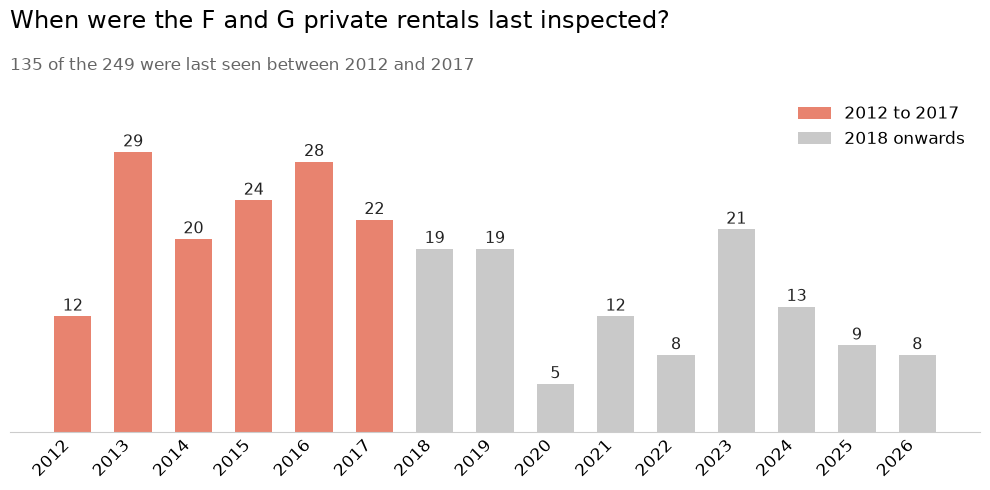

In [19]:
from matplotlib.patches import Patch

year_counts = fg['inspection_year'].value_counts().sort_index()
early = fg['inspection_year'].between(2012, 2017).sum()
old_c, new_c = '#e8836f', '#c9c9c9'

fig, ax = plt.subplots(figsize=(10, 5))

colours = [old_c if y <= 2017 else new_c for y in year_counts.index]
ax.bar(year_counts.index.astype(int), year_counts.values, color=colours, width=0.62)

for x, v in zip(year_counts.index.astype(int), year_counts.values):
    ax.text(x, v + 0.6, str(v), ha='center', fontsize=11.5, color='#222222')

ax.set_title("When were the F and G private rentals last inspected?",
             fontsize=17, loc='left', pad=45)
ax.text(0, 1.06, f"{early} of the {len(fg)} were last seen between 2012 and 2017",
        transform=ax.transAxes, fontsize=12.5, color='#666666')

ax.legend(handles=[Patch(facecolor=old_c), Patch(facecolor=new_c)],
          labels=['2012 to 2017', '2018 onwards'],
          frameon=False, fontsize=12, loc='upper right')

ax.set_ylim(0, year_counts.max() * 1.22)
ax.get_yaxis().set_visible(False)
for side in ['top', 'right', 'left']:
    ax.spines[side].set_visible(False)
ax.spines['bottom'].set_color('#cccccc')
ax.tick_params(axis='x', length=0, labelsize=12)
ax.set_xticks(year_counts.index.astype(int))
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig("../outputs/fg_inspection_years.png", dpi=150, bbox_inches='tight')
plt.show()

249 privately rented homes carry a latest certificate rated F or G. Only 51 were inspected in 2023 or later. 135 date from 2012 to 2017, so more than half rest on evidence at least eight years old, and some falls outside the ten year validity period of an EPC.

Against the register's own baseline that is twice as stale as it should be. 27.2% of all current Camden certificates rest on an inspection from 2012 to 2017. Among the F and G private rentals it is 54.2%. These are not simply old records in an old register, they are the oldest records in it.

The shape holds once volume is accounted for. F and G private rentals were 0.51% of the homes inspected in 2012 and 0.69% of those inspected in 2016, against 0.22% in 2026, so the fall is in the rate and not just the count. Two obvious explanations do not survive the comparison. Covid does not account for it, since overall inspections barely moved in 2020, 7,069 against 7,772 the year before, while F and G private rentals fell to five. And 2026 being a part year does not account for it either, since the share measure does not depend on the year being complete.

The fall after 2017 is consistent with the minimum standard taking effect from 2018, which would remove F and G homes from the lettings market as they are reinspected. That is the point. Enforcement reaches a home when someone looks at it. These 249 are the homes nobody has looked at.

Two explanations fit the remaining stock equally well. The homes are still F or G and have not been checked, or they were improved and never recertificated. Nothing requires a new certificate after improvement work, so the register cannot distinguish the two. The tenure caveat from earlier applies here as well: these are homes recorded as privately rented at their last inspection, and 36.5% of homes with more than one usable tenure record show a different tenure between them.

That is why the missing record status is rated Critical in the data quality report. A regulator working from this list would be acting on properties whose current condition is unknown, with no way to tell which ones.

## 9. Does the cleaning change the answer?

Every figure in this notebook rests on one decision: keep the latest certificate per home and
ignore the rest. The alternative, and the obvious thing to do with a downloaded file, is to
count every certificate.

If both give the same answer, the cleaning was tidying. If they differ, it changed the
conclusion. This compares the two directly.

In [20]:
def share_below_c(df, label):
    below = df['current_energy_rating'].isin(['D', 'E', 'F', 'G'])
    print(f"{label:28} {len(df):>7,} records, {below.sum():>7,} below band C ({below.mean()*100:.1f}%)")

share_below_c(work, "All certificates:")
share_below_c(homes, "One record per home:")
print()

for r in ['A', 'B', 'C', 'D', 'E', 'F', 'G']:
    raw = (work['current_energy_rating'] == r).mean() * 100
    clean = (homes['current_energy_rating'] == r).mean() * 100
    print(f"  {r}   all certificates {raw:5.1f}%   one per home {clean:5.1f}%   difference {clean-raw:+5.1f}")

All certificates:            102,185 records,  46,558 below band C (45.6%)
One record per home:          83,675 records,  35,605 below band C (42.6%)

  A   all certificates   0.1%   one per home   0.1%   difference  -0.0
  B   all certificates  11.6%   one per home  12.4%   difference  +0.7
  C   all certificates  42.7%   one per home  45.0%   difference  +2.3
  D   all certificates  34.8%   one per home  33.6%   difference  -1.2
  E   all certificates   8.9%   one per home   7.9%   difference  -1.0
  F   all certificates   1.5%   one per home   0.8%   difference  -0.6
  G   all certificates   0.4%   one per home   0.3%   difference  -0.2


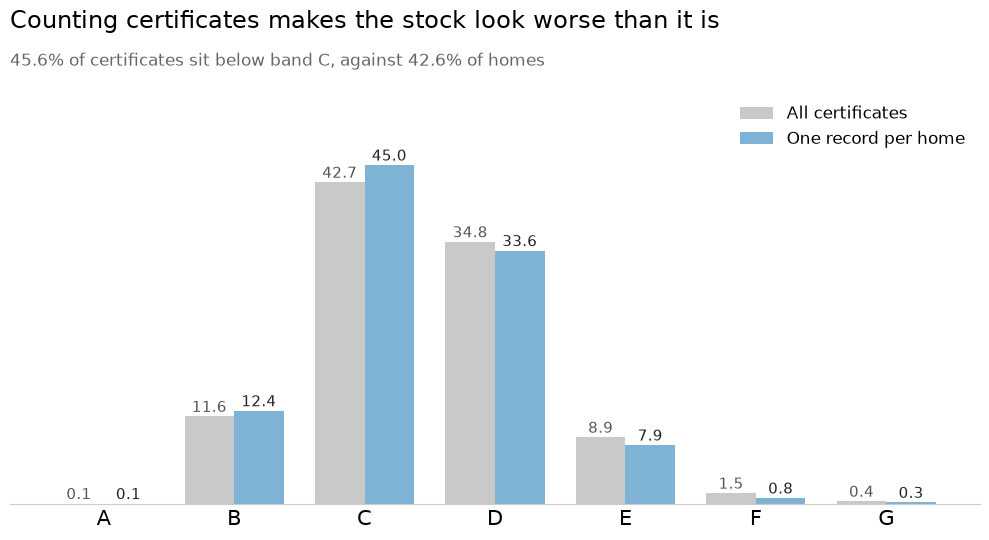

In [21]:
raw_pct = work['current_energy_rating'].value_counts(normalize=True).sort_index() * 100
clean_pct = homes['current_energy_rating'].value_counts(normalize=True).sort_index() * 100

raw_below = work['current_energy_rating'].isin(['D', 'E', 'F', 'G']).mean() * 100
clean_below = below_c.mean() * 100

x = range(len(raw_pct))
width = 0.38

fig, ax = plt.subplots(figsize=(10, 5.5))

ax.bar([i - width/2 for i in x], raw_pct.values, width,
       label='All certificates', color='#c9c9c9')
ax.bar([i + width/2 for i in x], clean_pct.values, width,
       label='One record per home', color='#7fb3d5')

for i in x:
    ax.text(i - width/2, raw_pct.values[i] + 0.6, f"{raw_pct.values[i]:.1f}",
            ha='center', fontsize=10.5, color='#555555')
    ax.text(i + width/2, clean_pct.values[i] + 0.6, f"{clean_pct.values[i]:.1f}",
            ha='center', fontsize=10.5, color='#222222')

ax.set_title("Counting certificates makes the stock look worse than it is",
             fontsize=17, loc='left', pad=45)
ax.text(0, 1.06,
        f"{raw_below:.1f}% of certificates sit below band C, against {clean_below:.1f}% of homes",
        transform=ax.transAxes, fontsize=12.5, color='#666666')

ax.legend(frameon=False, fontsize=12, loc='upper right')

ax.set_xticks(list(x))
ax.set_xticklabels(raw_pct.index, fontsize=15)
ax.set_ylim(0, max(raw_pct.max(), clean_pct.max()) * 1.22)
ax.get_yaxis().set_visible(False)
for side in ['top', 'right', 'left']:
    ax.spines[side].set_visible(False)
ax.spines['bottom'].set_color('#cccccc')
ax.tick_params(axis='x', length=0)

plt.tight_layout()
plt.savefig("../outputs/certificates_vs_homes.png", dpi=150, bbox_inches='tight')
plt.show()

Counting certificates gives 45.6% below band C. Counting homes gives 42.6%. Three percentage points on the headline figure.

The differences are not random. B and C are both understated in the raw count, D through G are all overstated, and only A is unchanged at 80 homes either way. F almost halves, from 1.5% to 0.8%.

The reason is what a superseded certificate is: the older record for a home that was certificated again later, usually because it was sold, re-let, or improved. Those records show the home before the work was done, so they carry the worse rating. Counting them means counting the same home twice, once as it is and once as it used to be.

So counting certificates does not only inflate the total. It makes the stock look worse than it is, because the duplicated records are weighted toward the pre-improvement state.

The deduplication in the cleaning notebook therefore changed the conclusion rather than tidying the data.

## 10. Summary

This notebook analysed 83,675 Camden homes, reduced from 102,185 certificates by keeping the most recent record for each property.

**Condition.** 42.6% of homes sit below band C, the standard privately rented homes must reach by 2030. 905 are at F or G, already unlawful to let privately without a registered exemption.

**Who the shortfall belongs to.** Of the 35,605 homes below band C, 14,090 are privately rented, 12,220 owner-occupied, and 7,485 socially rented. The enforceable problem is roughly 14,000 homes, not 35,605. A further 1,810 cannot be assigned to any tenure at all.

**Carbon.** Camden's homes emit 231,068 tonnes of CO2 a year and could emit 148,121, a saving of 82,947 tonnes or 35.9% using measures already written on the certificates. The figure holds when the flagged floor areas are excluded, so it does not rest on the records the audit found fault with.

**What that would take.** 80.4% of homes are heated by gas, so this is a heating problem before it is an insulation problem. Close to 20% are on a community network and cannot change their heating individually at all.

**What it is worth to a household.** A median of £140 a year, and 19.2% of homes gain nothing or are made worse off by the work their own certificate recommends. The emissions case is strong. The household case is not, and the certificates say so themselves.

**How old the evidence is.** 249 privately rented homes carry a current certificate rated F or G. 54.2% of them were last inspected between 2012 and 2017, against 27.2% of Camden certificates overall, so they are twice as stale as the register's own baseline. Nothing requires a new certificate after improvement work, so it is not possible to tell which of these homes are still F or G and which were fixed and never recertificated.

**Whether the cleaning mattered.** Counting certificates rather than homes puts 45.6% below band C instead of 42.6%, and overstates every band below C while understating B and C. Superseded records carry the pre-improvement rating, so the raw file does not only double count, it makes the stock look worse than it is. The deduplication changed the conclusion rather than tidying the data.

**The thread.** The profiling notebook found that where the register enforces a rule it holds perfectly, and where it does not, impossible records enter and persist. This notebook shows what that costs downstream. The tenure gap decides which law applies to a home. The missing record status decides whether an enforcement list describes the present or the past. Neither is a formatting problem.